In [ ]:
import pandas as pd
from rouge_score import rouge_scorer
import numpy as np 
from tqdm import tqdm
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("articles_with_multiple_summaries_3000.csv")

In [ ]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def compute_rouge_scores(generated_summary, reference_summary):
    if pd.isna(generated_summary) or pd.isna(reference_summary):
        return 0.0
        
    scores = scorer.score(reference_summary, generated_summary)
    
    rouge_1 = scores['rouge1'].fmeasure
    rouge_2 = scores['rouge2'].fmeasure
    rouge_l = scores['rougeL'].fmeasure
    
    average_rouge = (rouge_1 + rouge_2 + rouge_l) / 3
    
    return average_rouge

In [ ]:
rewards_short = []
rewards_medium = []
rewards_long = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    reward_short = compute_rouge_scores(row['summary_short'], row['Summary'])
    reward_medium = compute_rouge_scores(row['summary_medium'], row['Summary'])
    reward_long = compute_rouge_scores(row['summary_long'], row['Summary'])
    
    rewards_short.append(reward_short)
    rewards_medium.append(reward_medium)
    rewards_long.append(reward_long)

100%|██████████| 3000/3000 [00:37<00:00, 79.30it/s] 


In [ ]:
df['reward_short'] = rewards_short
df['reward_medium'] = rewards_medium
df['reward_long'] = rewards_long

In [ ]:
def get_rewards_order(row):
    scores = {
        'short': row['reward_short'],
        'medium': row['reward_medium'],
        'long': row['reward_long']
    }
    sorted_types = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    
    rewards_dict = {typ: 3-i for i, (typ, _) in enumerate(sorted_types)}
    
    return f"{rewards_dict['short']},{rewards_dict['medium']},{rewards_dict['long']}"

df['rewards'] = df.apply(get_rewards_order, axis=1)

/tmp/ipykernel_547878/2011130150.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['reward_short'], df['reward_medium'], df['reward_long']],


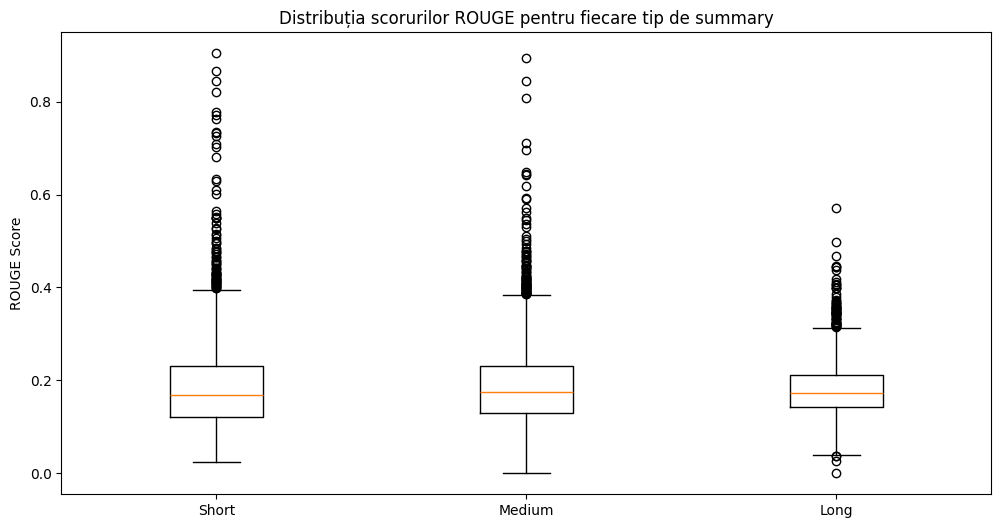

In [ ]:
plt.figure(figsize=(12, 6))
plt.boxplot([df['reward_short'], df['reward_medium'], df['reward_long']], 
            labels=['Short', 'Medium', 'Long'])
plt.title('Distribuția scorurilor ROUGE pentru fiecare tip de summary')
plt.ylabel('ROUGE Score')
plt.show()

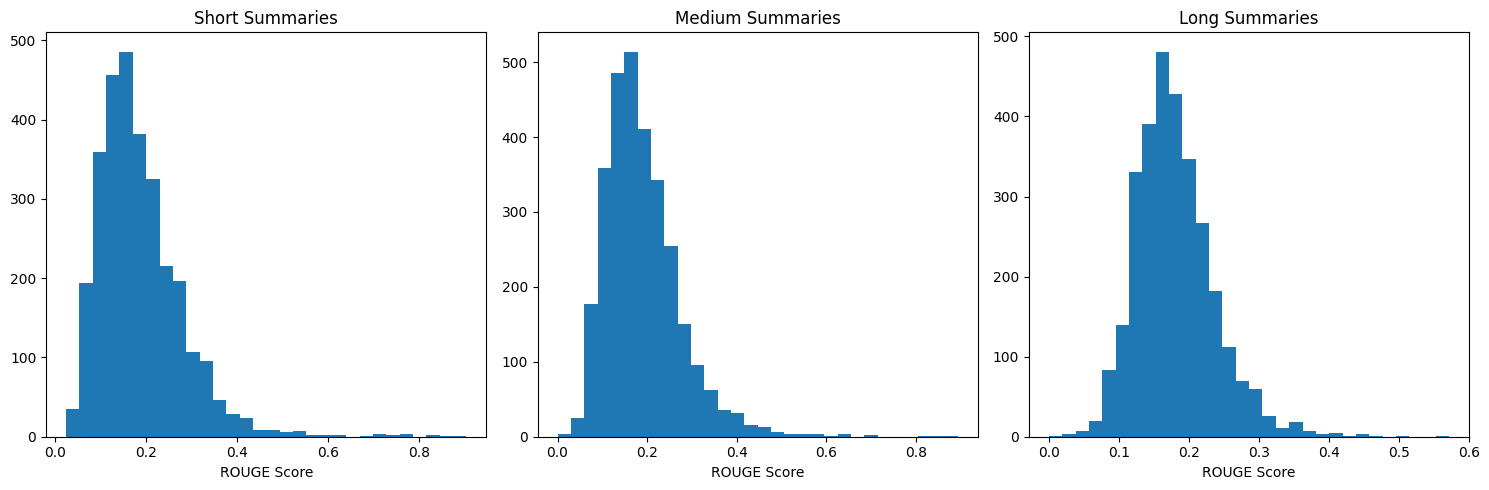

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.hist(df['reward_short'], bins=30)
ax1.set_title('Short Summaries')
ax1.set_xlabel('ROUGE Score')

ax2.hist(df['reward_medium'], bins=30)
ax2.set_title('Medium Summaries')
ax2.set_xlabel('ROUGE Score')

ax3.hist(df['reward_long'], bins=30)
ax3.set_title('Long Summaries')
ax3.set_xlabel('ROUGE Score')

plt.tight_layout()
plt.show()

In [ ]:
print(df[['Summary', 'reward_short', 'reward_medium', 'reward_long', 'rewards']].head())


Primele rânduri cu rewards:
                                             Summary  reward_short  \
0  Rocarta este o enciclopedie în format electron...      0.231123   
1  Muzica este arta combinării notelor în succesi...      0.108712   
2  O enciclopedie este un compendiu lexicografic,...      0.139077   
3   Wikipedia este o enciclopedie generală, dispo...      0.107898   
4  Geografia este știința care studiază relieful,...      0.103405   

   reward_medium  reward_long rewards  
0       0.151306     0.161241   3,1,2  
1       0.087719     0.068966   3,2,1  
2       0.152830     0.158826   1,2,3  
3       0.122342     0.146008   1,2,3  
4       0.071609     0.164291   2,1,3  


In [ ]:
df.to_csv('summaries_with_rewards_3000.csv', index=False)